# Analysis ModernBERT

In [1]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

model_id = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForMaskedLM.from_pretrained(model_id)

print("Model Layers:")
for name, layer in model.named_modules():
    num_params = sum(p.numel() for p in layer.parameters())
    print(f"{name}: {layer.__class__.__name__}, Parameters: {num_params:,}")


/Users/woutderijck/Documents/Masterproef/LoSparse/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model Layers:
: ModernBertForMaskedLM, Parameters: 149,655,232
model: ModernBertModel, Parameters: 149,014,272
model.embeddings: ModernBertEmbeddings, Parameters: 38,683,392
model.embeddings.tok_embeddings: Embedding, Parameters: 38,682,624
model.embeddings.norm: LayerNorm, Parameters: 768
model.embeddings.drop: Dropout, Parameters: 0
model.layers: ModuleList, Parameters: 110,330,112
model.layers.0: ModernBertEncoderLayer, Parameters: 5,014,272
model.layers.0.attn_norm: Identity, Parameters: 0
model.layers.0.attn: ModernBertAttention, Parameters: 2,359,296
model.layers.0.attn.Wqkv: Linear, Parameters: 1,769,472
model.layers.0.attn.rotary_emb: ModernBertRotaryEmbedding, Parameters: 0
model.layers.0.attn.Wo: Linear, Parameters: 589,824
model.layers.0.attn.out_drop: Identity, Parameters: 0
model.layers.0.mlp_norm: LayerNorm, Parameters: 768
model.layers.0.mlp: ModernBertMLP, Parameters: 2,654,208
model.layers.0.mlp.Wi: Linear, Parameters: 1,769,472
model.layers.0.mlp.act: GELUActivation, 

In [2]:
# Calculate total parameters in the model
total_params = sum(p.numel() for p in model.parameters())

# Get embedding layer parameters
embedding_params = sum(p.numel() for name, p in model.named_parameters() if 'embeddings' in name)

# Calculate and print the proportion
embedding_proportion = (embedding_params / total_params) * 100

print(f"Total parameters: {total_params:,}")
print(f"Embedding parameters: {embedding_params:,}")
print(f"Embedding proportion: {embedding_proportion:.2f}%")

Total parameters: 149,655,232
Embedding parameters: 38,683,392
Embedding proportion: 25.85%


# Dataset Vocabulary

In [3]:
from datasets import load_dataset

task_to_keys = {
    "cola": ("sentence", None),
    "mnli": ("premise", "hypothesis"),
    "mrpc": ("sentence1", "sentence2"),
    "qnli": ("question", "sentence"),
    "qqp": ("question1", "question2"),
    "rte": ("sentence1", "sentence2"),
    "sst2": ("sentence", None),
    "stsb": ("sentence1", "sentence2"),
    "wnli": ("sentence1", "sentence2"),
}

/var/folders/2b/rh5myd516gl7w1j3c4cmcmnc0000gn/T/ipykernel_88353/979399610.py:68: RuntimeWarning: divide by zero encountered in log
  y_fit = a * np.log(x_range) + b


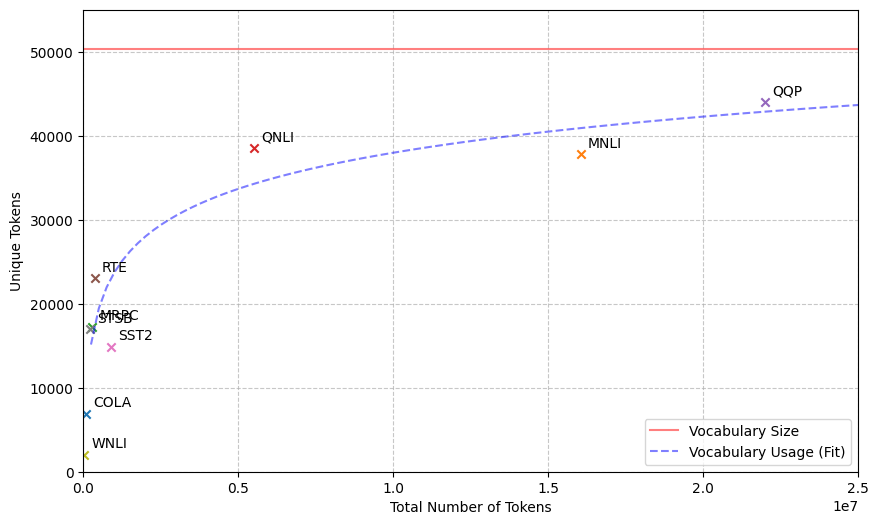

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset


def plot_vocabulary_usage():
    # Dictionary to store results
    results = {}
    vocab_size = None
    
    # Process each GLUE task
    for task_name in task_to_keys.keys():
        # Load dataset
        raw_datasets = load_dataset("glue", task_name)
        sentence1_key, sentence2_key = task_to_keys[task_name]
        
        # Initialize tokenizer
        tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
        if vocab_size is None:
            vocab_size = len(tokenizer)
        
        # Count total tokens and unique tokens
        total_tokens = 0
        unique_tokens = set()
        
        # Process all splits
        for split in raw_datasets.keys():
            # Process sentence1
            texts = raw_datasets[split][sentence1_key]
            for text in texts:
                tokens = tokenizer.tokenize(text)
                total_tokens += len(tokens)
                unique_tokens.update(tokens)
            
            # Process sentence2 if it exists
            if sentence2_key is not None:
                texts = raw_datasets[split][sentence2_key]
                for text in texts:
                    if text is not None:
                        tokens = tokenizer.tokenize(text)
                        total_tokens += len(tokens)
                        unique_tokens.update(tokens)
        
        results[task_name] = {
            'total_tokens': total_tokens,
            'unique_tokens': len(unique_tokens)
        }
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot vocabulary size line
    x_range = np.linspace(0, 25e6, 100)
    plt.axhline(y=vocab_size, color='red', linestyle='-', alpha=0.5, label='Vocabulary Size')
    
    # Plot data points
    for task, data in results.items():
        plt.scatter(data['total_tokens'], data['unique_tokens'], marker='x')
        plt.annotate(task.upper(), (data['total_tokens'], data['unique_tokens']), 
                    xytext=(5, 5), textcoords='offset points')
    
    # Add a fitted curve (using log function as it appears to be logarithmic)
    x_data = np.array([data['total_tokens'] for data in results.values()])
    y_data = np.array([data['unique_tokens'] for data in results.values()])
    
    # Fit logarithmic curve
    a, b = np.polyfit(np.log(x_data), y_data, 1)
    y_fit = a * np.log(x_range) + b
    plt.plot(x_range, y_fit, '--', color='blue', alpha=0.5, label='Vocabulary Usage (Fit)')
    
    # Customize the plot
    plt.xlabel('Total Number of Tokens')
    plt.ylabel('Unique Tokens')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Set axis limits
    plt.xlim(0, 25e6)
    plt.ylim(0, 55000)
    
    return plt.gcf()

# Generate the plot
fig = plot_vocabulary_usage()
plt.show()

# Dynamic Embedding Pruning (DEP)

In [5]:
# Step 1: Get the dataset vocabulary for a specific GLUE task
def get_dataset_vocabulary(task_name):
    # Load the dataset
    raw_datasets = load_dataset("glue", task_name)
    sentence1_key, sentence2_key = task_to_keys[task_name]
    
    # Initialize tokenizer
    tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
    
    # Set to store unique token IDs
    unique_token_ids = set()
    
    # Process all splits
    for split in raw_datasets.keys():
        # Process sentence1
        texts = raw_datasets[split][sentence1_key]
        for text in texts:
            # Get token IDs instead of tokens
            token_ids = tokenizer.encode(text, add_special_tokens=True)
            unique_token_ids.update(token_ids)
        
        # Process sentence2 if it exists
        if sentence2_key is not None:
            texts = raw_datasets[split][sentence2_key]
            for text in texts:
                if text is not None:
                    token_ids = tokenizer.encode(text, add_special_tokens=True)
                    unique_token_ids.update(token_ids)
    
    return sorted(list(unique_token_ids))  # Convert to sorted list for consistent mapping

In [6]:
import torch

# Step 2: Create the mapping function and reduced embedding matrix
def create_reduced_embeddings(task_vocab, model):
    # Create mapping from original token IDs to new consecutive IDs
    token_map = {old_id: new_id for new_id, old_id in enumerate(task_vocab)}
    
    # Get original embedding matrix
    original_embeddings = model.model.embeddings.tok_embeddings.weight.data
    
    # Create new embedding matrix with only the needed vectors
    reduced_embeddings = torch.stack([original_embeddings[i] for i in task_vocab])
    
    return token_map, reduced_embeddings

In [7]:
# Test the functions
task_vocab = get_dataset_vocabulary("sst2")
print(f"Original vocab size: {len(tokenizer)}")
print(f"Task vocab size: {len(task_vocab)}")

token_map, reduced_embeddings = create_reduced_embeddings(task_vocab, model)
print(f"Original embedding shape: {model.model.embeddings.tok_embeddings.weight.shape}")
print(f"Reduced embedding shape: {reduced_embeddings.shape}")

Original vocab size: 50368
Task vocab size: 14894
Original embedding shape: torch.Size([50368, 768])
Reduced embedding shape: torch.Size([14894, 768])


In [8]:
# Step 3: Create function to transform dataset using new token mappings
def transform_dataset(dataset, tokenizer, token_map, task_name):
    sentence1_key, sentence2_key = task_to_keys[task_name]
    
    def transform_text(text):
        # Get original token IDs
        token_ids = tokenizer.encode(text, add_special_tokens=True)
        # Map to new IDs
        new_token_ids = [token_map[tid] for tid in token_ids]
        return new_token_ids
    
    transformed_datasets = {}
    
    # Process all splits
    for split in dataset.keys():
        # Transform sentence1
        texts1 = dataset[split][sentence1_key]
        transformed_texts1 = [transform_text(text) for text in texts1]
        
        # Transform sentence2 if it exists
        transformed_texts2 = None
        if sentence2_key is not None:
            texts2 = dataset[split][sentence2_key]
            transformed_texts2 = [transform_text(text) if text is not None else None 
                                for text in texts2]
        
        # Store transformed data
        transformed_datasets[split] = {
            'input_ids1': transformed_texts1,
            'input_ids2': transformed_texts2,
            'labels': dataset[split]['label']
        }
    
    return transformed_datasets

# Test the function
raw_datasets = load_dataset("glue", "sst2")
transformed_datasets = transform_dataset(raw_datasets, tokenizer, token_map, "sst2")
print(f"Sample original text IDs: {tokenizer.encode(raw_datasets['train']['sentence'][0])}")
print(f"Sample transformed IDs: {transformed_datasets['train']['input_ids1'][0]}")

Sample original text IDs: [50281, 21179, 747, 4279, 621, 432, 253, 17087, 5085, 209, 50282]
Sample transformed IDs: [14892, 9338, 470, 2783, 363, 210, 57, 8164, 3242, 50, 14893]


In [9]:
import copy
import torch.nn as nn

# Step 4: Create a wrapper class for dynamic vocabulary pruning
class DynamicVocabPruner:
    def __init__(self, model_id, task_name):
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.model = AutoModelForMaskedLM.from_pretrained(model_id)
        self.task_name = task_name
        
        # Get task vocabulary and create mappings
        self.task_vocab = get_dataset_vocabulary(task_name)
        self.token_map, self.reduced_embeddings = create_reduced_embeddings(
            self.task_vocab, self.model
        )
        
        # Store original embedding size for reference
        self.original_vocab_size = len(self.tokenizer)
        self.reduced_vocab_size = len(self.task_vocab)
        
    def transform_dataset(self, dataset):
        return transform_dataset(dataset, self.tokenizer, self.token_map, self.task_name)
    
    def get_reduced_model(self):
        # Create a copy of the model with reduced embeddings
        model_copy = copy.deepcopy(self.model)
        model_copy.bert.embeddings.word_embeddings = nn.Embedding.from_pretrained(
            self.reduced_embeddings, freeze=False
        )
        return model_copy
    
    def print_stats(self):
        reduction = (1 - len(self.task_vocab)/len(self.tokenizer)) * 100
        print(f"Original vocabulary size: {self.original_vocab_size:,}")
        print(f"Reduced vocabulary size: {self.reduced_vocab_size:,}")
        print(f"Vocabulary reduction: {reduction:.2f}%")
        
        orig_embed_params = self.original_vocab_size * self.reduced_embeddings.shape[1]
        new_embed_params = self.reduced_vocab_size * self.reduced_embeddings.shape[1]
        print(f"\nOriginal embedding parameters: {orig_embed_params:,}")
        print(f"Reduced embedding parameters: {new_embed_params:,}")
        print(f"Pruning ratio: {new_embed_params/orig_embed_params*100:.2f}%")

# Test the class
pruner = DynamicVocabPruner("answerdotai/ModernBERT-base", "sst2")
pruner.print_stats()

Original vocabulary size: 50,368
Reduced vocabulary size: 14,894
Vocabulary reduction: 70.43%

Original embedding parameters: 38,682,624
Reduced embedding parameters: 11,438,592
Pruning ratio: 29.57%


# Evaluation

In [10]:
import numpy as np
import pandas as pd
import torch
from functools import partial
import os

from datasets import load_dataset
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)

from sklearn.metrics import matthews_corrcoef, accuracy_score
from scipy.stats import pearsonr, spearmanr

os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [11]:
glue_tasks = {
    "cola": {
        "abbr": "CoLA",
        "name": "Corpus of Linguistic Acceptability",
        "description": "Predict whether a sequence is a grammatical English sentence",
        "task_type": "Single-Sentence Task",
        "domain": "Misc.",
        "size": "8.5k",
        "metrics": "Matthews corr.",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["sentence"],
        "target": "label",
        "metric_funcs": [matthews_corrcoef],
        "n_labels": 2,
    },
    "sst2": {
        "abbr": "SST-2",
        "name": "Stanford Sentiment Treebank",
        "description": "Predict the sentiment of a given sentence",
        "task_type": "Single-Sentence Task",
        "domain": "Movie reviews",
        "size": "67k",
        "metrics": "Accuracy",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["sentence"],
        "target": "label",
        "metric_funcs": [accuracy_score],
        "n_labels": 2,
    },
    "mrpc": {
        "abbr": "MRPC",
        "name": "Microsoft Research Paraphrase Corpus",
        "description": "Predict whether two sentences are semantically equivalent",
        "task_type": "Similarity and Paraphrase Tasks",
        "domain": "News",
        "size": "3.7k",
        "metrics": "F1/Accuracy",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["sentence1", "sentence2"],
        "target": "label",
        "metric_funcs": [accuracy_score, f1_score],
        "n_labels": 2,
    },
    "stsb": {
        "abbr": "SST-B",
        "name": "Semantic Textual Similarity Benchmark",
        "description": "Predict the similarity score for two sentences on a scale from 1 to 5",
        "task_type": "Similarity and Paraphrase Tasks",
        "domain": "Misc.",
        "size": "7k",
        "metrics": "Pearson/Spearman corr.",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["sentence1", "sentence2"],
        "target": "label",
        "metric_funcs": [pearsonr, spearmanr],
        "n_labels": 1,
    },
    "qqp": {
        "abbr": "QQP",
        "name": "Quora question pair",
        "description": "Predict if two questions are a paraphrase of one another",
        "task_type": "Similarity and Paraphrase Tasks",
        "domain": "Social QA questions",
        "size": "364k",
        "metrics": "F1/Accuracy",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["question1", "question2"],
        "target": "label",
        "metric_funcs": [f1_score, accuracy_score],
        "n_labels": 2,
    },
    "mnli-matched": {
        "abbr": "MNLI",
        "name": "Mulit-Genre Natural Language Inference",
        "description": "Predict whether the premise entails, contradicts or is neutral to the hypothesis",
        "task_type": "Inference Tasks",
        "domain": "Misc.",
        "size": "393k",
        "metrics": "Accuracy",
        "dataset_names": {"train": "train", "valid": "validation_matched", "test": "test_matched"},
        "inputs": ["premise", "hypothesis"],
        "target": "label",
        "metric_funcs": [accuracy_score],
        "n_labels": 3,
    },
    "mnli-mismatched": {
        "abbr": "MNLI",
        "name": "Mulit-Genre Natural Language Inference",
        "description": "Predict whether the premise entails, contradicts or is neutral to the hypothesis",
        "task_type": "Inference Tasks",
        "domain": "Misc.",
        "size": "393k",
        "metrics": "Accuracy",
        "dataset_names": {"train": "train", "valid": "validation_mismatched", "test": "test_mismatched"},
        "inputs": ["premise", "hypothesis"],
        "target": "label",
        "metric_funcs": [accuracy_score],
        "n_labels": 3,
    },
    "qnli": {
        "abbr": "QNLI",
        "name": "Stanford Question Answering Dataset",
        "description": "Predict whether the context sentence contains the answer to the question",
        "task_type": "Inference Tasks",
        "domain": "Wikipedia",
        "size": "105k",
        "metrics": "Accuracy",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["question", "sentence"],
        "target": "label",
        "metric_funcs": [accuracy_score],
        "n_labels": 2,
    },
    "rte": {
        "abbr": "RTE",
        "name": "Recognize Textual Entailment",
        "description": "Predict whether one sentece entails another",
        "task_type": "Inference Tasks",
        "domain": "News, Wikipedia",
        "size": "2.5k",
        "metrics": "Accuracy",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["sentence1", "sentence2"],
        "target": "label",
        "metric_funcs": [accuracy_score],
        "n_labels": 2,
    },
    "wnli": {
        "abbr": "WNLI",
        "name": "Winograd Schema Challenge",
        "description": "Predict if the sentence with the pronoun substituted is entailed by the original sentence",
        "task_type": "Inference Tasks",
        "domain": "Fiction books",
        "size": "634",
        "metrics": "Accuracy",
        "dataset_names": {"train": "train", "valid": "validation", "test": "test"},
        "inputs": ["sentence1", "sentence2"],
        "target": "label",
        "metric_funcs": [accuracy_score],
        "n_labels": 2,
    },
}

# for v in glue_tasks.values(): print(v)
glue_tasks.values()

glue_df = pd.DataFrame(glue_tasks.values(), columns=["abbr", "name", "task_type", "description", "size", "metrics"])
glue_df.columns = glue_df.columns.str.replace("_", " ").str.capitalize()
display(glue_df.style.set_properties(**{"text-align": "left"}))


,Abbr,Name,Task type,Description,Size,Metrics
0,CoLA,Corpus of Linguistic Acceptability,Single-Sentence Task,Predict whether a sequence is a grammatical English sentence,8.5k,Matthews corr.
1,SST-2,Stanford Sentiment Treebank,Single-Sentence Task,Predict the sentiment of a given sentence,67k,Accuracy
2,MRPC,Microsoft Research Paraphrase Corpus,Similarity and Paraphrase Tasks,Predict whether two sentences are semantically equivalent,3.7k,F1/Accuracy
3,SST-B,Semantic Textual Similarity Benchmark,Similarity and Paraphrase Tasks,Predict the similarity score for two sentences on a scale from 1 to 5,7k,Pearson/Spearman corr.
4,QQP,Quora question pair,Similarity and Paraphrase Tasks,Predict if two questions are a paraphrase of one another,364k,F1/Accuracy
5,MNLI,Mulit-Genre Natural Language Inference,Inference Tasks,"Predict whether the premise entails, contradicts or is neutral to the hypothesis",393k,Accuracy
6,MNLI,Mulit-Genre Natural Language Inference,Inference Tasks,"Predict whether the premise entails, contradicts or is neutral to the hypothesis",393k,Accuracy
7,QNLI,Stanford Question Answering Dataset,Inference Tasks,Predict whether the context sentence contains the answer to the question,105k,Accuracy
8,RTE,Recognize Textual Entailment,Inference Tasks,Predict whether one sentece entails another,2.5k,Accuracy
9,WNLI,Winograd Schema Challenge,Inference Tasks,Predict if the sentence with the pronoun substituted is entailed by the original sentence,634,Accuracy


In [12]:
# Step 1: Setup the model with reduced vocabulary
def setup_reduced_model(task_name, checkpoint="answerdotai/ModernBERT-base"):
    # Get task metadata
    task_meta = glue_tasks[task_name]
    n_labels = task_meta["n_labels"]
    task_metrics = task_meta["metric_funcs"]
    
    # Get dataset vocabulary and create mappings
    task_vocab = get_dataset_vocabulary(task_name)
    
    # Load model and create reduced embeddings
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=n_labels)
    token_map, reduced_embeddings = create_reduced_embeddings(task_vocab, model)
    
    # Replace embedding layer with reduced version
    model.model.embeddings.tok_embeddings = nn.Embedding.from_pretrained(
        reduced_embeddings, freeze=False
    )
    
    return model, token_map, task_metrics

In [13]:
from datasets import Dataset

# Step 2: Prepare datasets with reduced vocabulary
def prepare_reduced_datasets(task_name, token_map, tokenizer):
    # Load dataset
    raw_datasets = load_dataset("glue", task_name)
    task_meta = glue_tasks[task_name]
    train_ds_name = task_meta["dataset_names"]["train"]
    valid_ds_name = task_meta["dataset_names"]["valid"]
    sentence1_key, sentence2_key = task_to_keys[task_name]
    
    def transform_split(dataset_split):
        transformed_data = []
        
        for i in range(len(dataset_split[sentence1_key])):
            item = {}
            
            # Get text(s)
            text1 = dataset_split[sentence1_key][i]
            text2 = None if sentence2_key is None else dataset_split[sentence2_key][i]
            
            # Tokenize
            if text2 is None:
                encoded = tokenizer(text1, add_special_tokens=True)
            else:
                encoded = tokenizer(text1, text2, add_special_tokens=True)
            
            # Map token IDs to new vocabulary
            item['input_ids'] = [token_map[tid] for tid in encoded['input_ids']]
            item['attention_mask'] = encoded['attention_mask']
            item['labels'] = dataset_split['label'][i]
            
            transformed_data.append(item)
        
        return Dataset.from_list(transformed_data)
    
    # Transform train and validation sets
    train_dataset = transform_split(raw_datasets[train_ds_name])
    eval_dataset = transform_split(raw_datasets[valid_ds_name])
    
    return train_dataset, eval_dataset

In [14]:
# Step 3: Create data collator for reduced vocabulary
class ReducedVocabDataCollator:
    def __init__(self, pad_token_id):
        self.pad_token_id = pad_token_id
        
    def __call__(self, features):
        # Get max length in batch
        max_length = max(len(x['input_ids']) for x in features)
        
        # Pad input_ids and attention masks
        input_ids = []
        attention_mask = []
        labels = []
        
        for f in features:
            # Pad input_ids
            padded = f['input_ids'] + [self.pad_token_id] * (max_length - len(f['input_ids']))
            input_ids.append(padded)
            
            # Pad attention mask
            mask = f['attention_mask'] + [0] * (max_length - len(f['attention_mask']))
            attention_mask.append(mask)
            
            # Get labels
            labels.append(f['labels'])
        
        return {
            'input_ids': torch.tensor(input_ids),
            'attention_mask': torch.tensor(attention_mask),
            'labels': torch.tensor(labels)
        }

In [15]:
def compute_metrics(eval_pred, task_metrics):
    predictions, labels = eval_pred

    metrics_d = {}
    for metric_func in task_metrics:
        metric_name = metric_func.__name__
        if metric_name in ["pearsonr", "spearmanr"]:
            score = metric_func(labels, np.squeeze(predictions))
        else:
            score = metric_func(np.argmax(predictions, axis=-1), labels)

        if isinstance(score, tuple):
            metrics_d[metric_func.__name__] = score[0]
        else:
            metrics_d[metric_func.__name__] = score

    return metrics_d

In [16]:
# Step 4: Setup training
def setup_reduced_training(model, train_dataset, eval_dataset, task_metrics):
    # Training hyperparameters
    training_args = TrainingArguments(
        output_dir="reduced_modernbert_glue_ft",
        learning_rate=8e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=10,
        lr_scheduler_type="linear",
        optim="adamw_torch",
        adam_beta1=0.9,
        adam_beta2=0.98,
        adam_epsilon=1e-6,
        weight_decay=8e-6,
        logging_strategy="epoch",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        bf16=True,
        bf16_full_eval=True,
        push_to_hub=False,
    )
    
    # Create data collator
    data_collator = ReducedVocabDataCollator(pad_token_id=0)
    
    # Setup trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=partial(compute_metrics, task_metrics=task_metrics),
    )
    
    return trainer

In [17]:
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.training_history = {"train": [], "eval": []}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if "loss" in logs:  # Training logs
                self.training_history["train"].append(logs)
            elif "eval_loss" in logs:  # Evaluation logs
                self.training_history["eval"].append(logs)

In [18]:
# Step 5: Run the evaluation
def evaluate_reduced_model(task_name="mrpc"):
    print(f"Evaluating reduced vocabulary model on {task_name}")
    
    # Setup model with reduced vocabulary
    model, token_map, task_metrics = setup_reduced_model(task_name)
    
    # Initialize tokenizer
    tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
    
    # Prepare datasets
    train_dataset, eval_dataset = prepare_reduced_datasets(task_name, token_map, tokenizer)
    
    # Setup trainer
    trainer = setup_reduced_training(model, train_dataset, eval_dataset, task_metrics)
    
    # Add metrics callback
    metrics_callback = MetricsCallback()
    trainer.add_callback(metrics_callback)
    
    # Train and evaluate
    trainer.train()
    
    # Get training history
    train_history_df = pd.DataFrame(metrics_callback.training_history["train"])
    train_history_df = train_history_df.add_prefix("train_")
    eval_history_df = pd.DataFrame(metrics_callback.training_history["eval"])
    train_res_df = pd.concat([train_history_df, eval_history_df], axis=1)
    
    return train_res_df, trainer.model

In [19]:
# Run evaluation
train_res_df, reduced_model = evaluate_reduced_model("mrpc")
display(train_res_df)

Evaluating reduced vocabulary model on mrpc


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/woutderijck/Documents/Masterproef/LoSparse/venv/lib/python3.11/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
 10%|█         | 115/1150 [02:15<19:18,  1.12s/it]

{'loss': 0.5189, 'grad_norm': 5.75119686126709, 'learning_rate': 7.2e-05, 'epoch': 1.0}


                                                  
 10%|█         | 115/1150 [02:20<19:18,  1.12s/it]

{'eval_loss': 0.35411033034324646, 'eval_accuracy_score': 0.8308823529411765, 'eval_f1_score': 0.883248730964467, 'eval_runtime': 4.8326, 'eval_samples_per_second': 84.426, 'eval_steps_per_second': 2.69, 'epoch': 1.0}


...

                                                   
100%|██████████| 1150/1150 [23:11<00:00,  1.01it/s]

{'eval_loss': 0.8472970724105835, 'eval_accuracy_score': 0.8897058823529411, 'eval_f1_score': 0.9183303085299456, 'eval_runtime': 4.725, 'eval_samples_per_second': 86.35, 'eval_steps_per_second': 2.751, 'epoch': 10.0}


100%|██████████| 1150/1150 [23:13<00:00,  1.21s/it]

{'train_runtime': 1393.8789, 'train_samples_per_second': 26.315, 'train_steps_per_second': 0.825, 'train_loss': 0.10139985889196396, 'epoch': 10.0}


,train_loss,train_grad_norm,train_learning_rate,train_epoch,eval_loss,eval_accuracy_score,eval_f1_score,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.5189,5.751197,0.000072,1.0,0.354110,0.830882,0.883249,4.8326,84.426,2.690,1.0
1,0.2725,3.737277,0.000064,2.0,0.336121,0.848039,0.897351,4.9494,82.435,2.627,2.0
2,0.1086,0.898849,0.000056,3.0,0.354872,0.887255,0.918440,4.5811,89.061,2.838,3.0
3,0.0522,0.403023,0.000048,4.0,0.473981,0.865196,0.906303,4.4989,90.689,2.890,4.0
4,0.0311,0.003235,0.000040,5.0,0.675988,0.872549,0.908451,4.8668,83.833,2.671,5.0
5,0.0162,0.162854,0.000032,6.0,0.739875,0.865196,0.904679,4.5363,89.942,2.866,6.0
6,0.0087,0.002567,0.000024,7.0,0.698882,0.884804,0.916221,4.7830,85.302,2.718,7.0
7,0.0040,0.000472,0.000016,8.0,0.757579,0.870098,0.905861,4.5750,89.180,2.842,8.0
8,0.0010,0.001032,0.000008,9.0,0.848691,0.867647,0.905263,4.3114,94.633,3.015,9.0
9,0.0006,0.002796,0.000000,10.0,0.847297,0.889706,0.918330,4.7250,86.350,2.751,10.0


In [20]:
def count_model_parameters(model):
    """Count total, trainable, and embedding parameters in the model"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    embedding_params = sum(p.numel() for name, p in model.named_parameters() if 'embeddings' in name)
    
    # Count parameters in decoder (output layer)
    decoder_params = sum(p.numel() for name, p in model.named_parameters() if 'decoder' in name)
    
    # Calculate actual model size (excluding embeddings and decoder)
    model_only_params = total_params - embedding_params - decoder_params
    
    print("\n=== Model Parameter Statistics ===")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Embedding parameters: {embedding_params:,} ({embedding_params/total_params*100:.2f}%)")
    print(f"Decoder parameters: {decoder_params:,} ({decoder_params/total_params*100:.2f}%)")
    print(f"Model-only parameters: {model_only_params:,} ({model_only_params/total_params*100:.2f}%)")
    
    return {
        'total': total_params,
        'trainable': trainable_params,
        'embedding': embedding_params,
        'decoder': decoder_params,
        'model_only': model_only_params
    }

# After training, evaluate the model parameters
print("\nOriginal model parameters:")
original_params = count_model_parameters(model)

print("\nReduced model parameters:")
reduced_params = count_model_parameters(reduced_model)

# Calculate reduction percentages
print("\n=== Parameter Reduction Statistics ===")
for param_type in ['total', 'embedding', 'model_only']:
    reduction = (original_params[param_type] - reduced_params[param_type]) / original_params[param_type] * 100
    print(f"{param_type.title()} parameter reduction: {reduction:.2f}%")


Original model parameters:

=== Model Parameter Statistics ===
Total parameters: 149,655,232
Trainable parameters: 149,655,232
Embedding parameters: 38,683,392 (25.85%)
Decoder parameters: 50,368 (0.03%)
Model-only parameters: 110,921,472 (74.12%)

Reduced model parameters:

=== Model Parameter Statistics ===
Total parameters: 124,144,898
Trainable parameters: 124,144,898
Embedding parameters: 13,221,888 (10.65%)
Decoder parameters: 0 (0.00%)
Model-only parameters: 110,923,010 (89.35%)

=== Parameter Reduction Statistics ===
Total parameter reduction: 17.05%
Embedding parameter reduction: 65.82%
Model_Only parameter reduction: -0.00%
